# METR/ECE 5683 Assignment #2: Polarimetric Radar Data Processing

The goal of this assignment is to learn about different polarimetric radar retrievals and correction methods in Py-ART. For more information about the Py-ART library, visit https://arm-doe.github.io/pyart/. To learn more about a particular algorithm, you can click on the link for the specific algorithm for a short description. There is also a link to the source code ([source]) where you can see exactly how the algorithm is implemented. 

# Guidance for Plots

For all radar plots, please choose an appropriate zoom that highlights the meteorological features of interest (e.g., zoom in to remove areas of no echoes). Please ensure that all axes are appropriately labeled and a descriptive title is included. For example, the title or a text annotation should be included to differentiate different KDP methods or attenuation correction schemes.

# Library Imports

The code below imports necessary libraries for the assignment. You can add other import statements as needed.

In [1]:
import pyart
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import rc
from matplotlib.ticker import MultipleLocator
import os
from netCDF4 import num2date
import cartopy
import numpy as np
from datetime import datetime
import pandas as pd
from numpy.matlib import repmat
import sys
sys.path.append("/Users/robbyfrost/Documents/Classes/Radar_Applications/")
import radarlib as rlib

# plotting setup
plt.rcParams['axes.titleweight'] = 'normal'
plt.rcParams['axes.labelweight'] = 'normal'
plt.rcParams['text.latex.preamble'] = r'\usepackage{bm}'
rc('font', family='sans-serif')
rc('font', weight='normal', size=12.5)
rc('figure', facecolor='white')


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



# 1) Read Py-ART File 

The PX-1000 radar was deployed during the ESCAPE field campaign in Houston, which focused on understanding the lifecycle of deep convection. Some of the best data were collected on 27 June 2022 when several thunderstorms developed close to the PX-1000 X-band dual-polarization radar.

Under Course Information and Resources, click the Course Radar Data link. Click on the MobileRadar folder and download the PX-1000 CF/Radial netCDF file data file that contains data collected at 2112:40 UTC on 27 June 2022. 

a) Use Py-ART to read in the radar file to a radar object.

b) Familiarize yourself with the variable names using radar.fields.keys(). 

c) Convert the PHIDP data from radians to degrees.

Note: No written description is needed for this question.

In [2]:
drad = "/Users/robbyfrost/Documents/Classes/Radar_Applications/hw2/cfrad.20220627_211240_PX1000_v47_s444.nc"
radar = pyart.io.read(drad)

r = radar.range['data']
az = radar.azimuth['data']
el = radar.elevation['data']
nr = r.size
naz = az.size
nel = el.size

tstr = f"{radar.time['units'][-20:-10]} {radar.time['units'][-9:-1]} UTC"

In [3]:
phidp = radar.fields['PHIDP']['data']
radar.fields['PHIDP']['data'] = phidp * 180 / np.pi

# 2) Applying a Gatefilter

To avoid performing calculations on poor or noisy data, create a gatefilter that eliminates echoes less than -10 dBZ and $\rho_{HV}$ less than 0.8. You are welcome to experiment with different thresholds or adding other variables to improve data quality.

In [4]:
ref = radar.fields['DBZ']['data']
rhohv = radar.fields['RHOHV']['data']

gf_mask = (ref < -10) & (rhohv < 0.8)

gf = pyart.filters.GateFilter(radar)
gf.exclude_gates(gf_mask)

# 3) Calculate Specific Differential Phase Using Different KDP Methods

The different approaches to estimating $K_{DP}$ have different advantages and disadvantages, including estimation accuracy or differences in computational time. While the default parameters may work well in some cases, you may not always obtain good results. Thus, it is best to try to optimize the $K_{DP}$ estimation parameters for each method before applying them to large samples of data. 

For each of the cases below, calculate specific differential phase using the settings described below. For documentation on the Py-ART $K_{DP}$ algorithms, see the <a href="https://arm-doe.github.io/pyart/API/generated/pyart.retrieve.html">retrieve module</a> for details. To make plots of KDP using Py-ART, you will need to add $K_{DP}$ to the radar dictionary. To do this, follow the following procedure (shown for Vulpiani as an example):
```python
kdp_dict = pyart.retrieve.kdp_vulpiani(your_arguments_here)
radar.add_field('kdp_vulpiani',kdp_dict[0],replace_existing=True)
```

a) For the file above, calculate specific differential phase ($K_{DP}$) using Vulpiani, Maesaka, and Schneebeli methods using the following parameters:
- Vulpiani: Number of iterations=10, window size=10, band = 'X', psidp_field='PHIDP'
- Maesaka: band = 'X', Clpf=1.0e-4, psidp_field='PHIDP'
- Schneebeli: band = 'X', psidp_field='PHIDP'

Create a plot to compare the estimated $K_{DP}$ from each method.

In [5]:
# Vulpiani
kdp_dict = pyart.retrieve.kdp_vulpiani(radar, 
                                       gatefilter=gf,
                                       n_iter=10,
                                       windsize=10,
                                       band='X',
                                       psidp_field='PHIDP')
radar.add_field('KDP_VULPIANI', kdp_dict[0], replace_existing=True)

# Maesaka
kdp_dict = pyart.retrieve.kdp_maesaka(radar,
                                      gatefilter=gf,
                                      band='X',
                                      Clpf=1e-4,
                                      psidp_field='PHIDP')
radar.add_field('KDP_MAESAKA', kdp_dict[0], replace_existing=True)

# Schneebeli
kdp_dict = pyart.retrieve.kdp_schneebeli(radar,
                                         gatefilter=gf,
                                         band='X',
                                         psidp_field='PHIDP')
radar.add_field('KDP_SCHNEEBELI', kdp_dict[0], replace_existing=True)


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather 

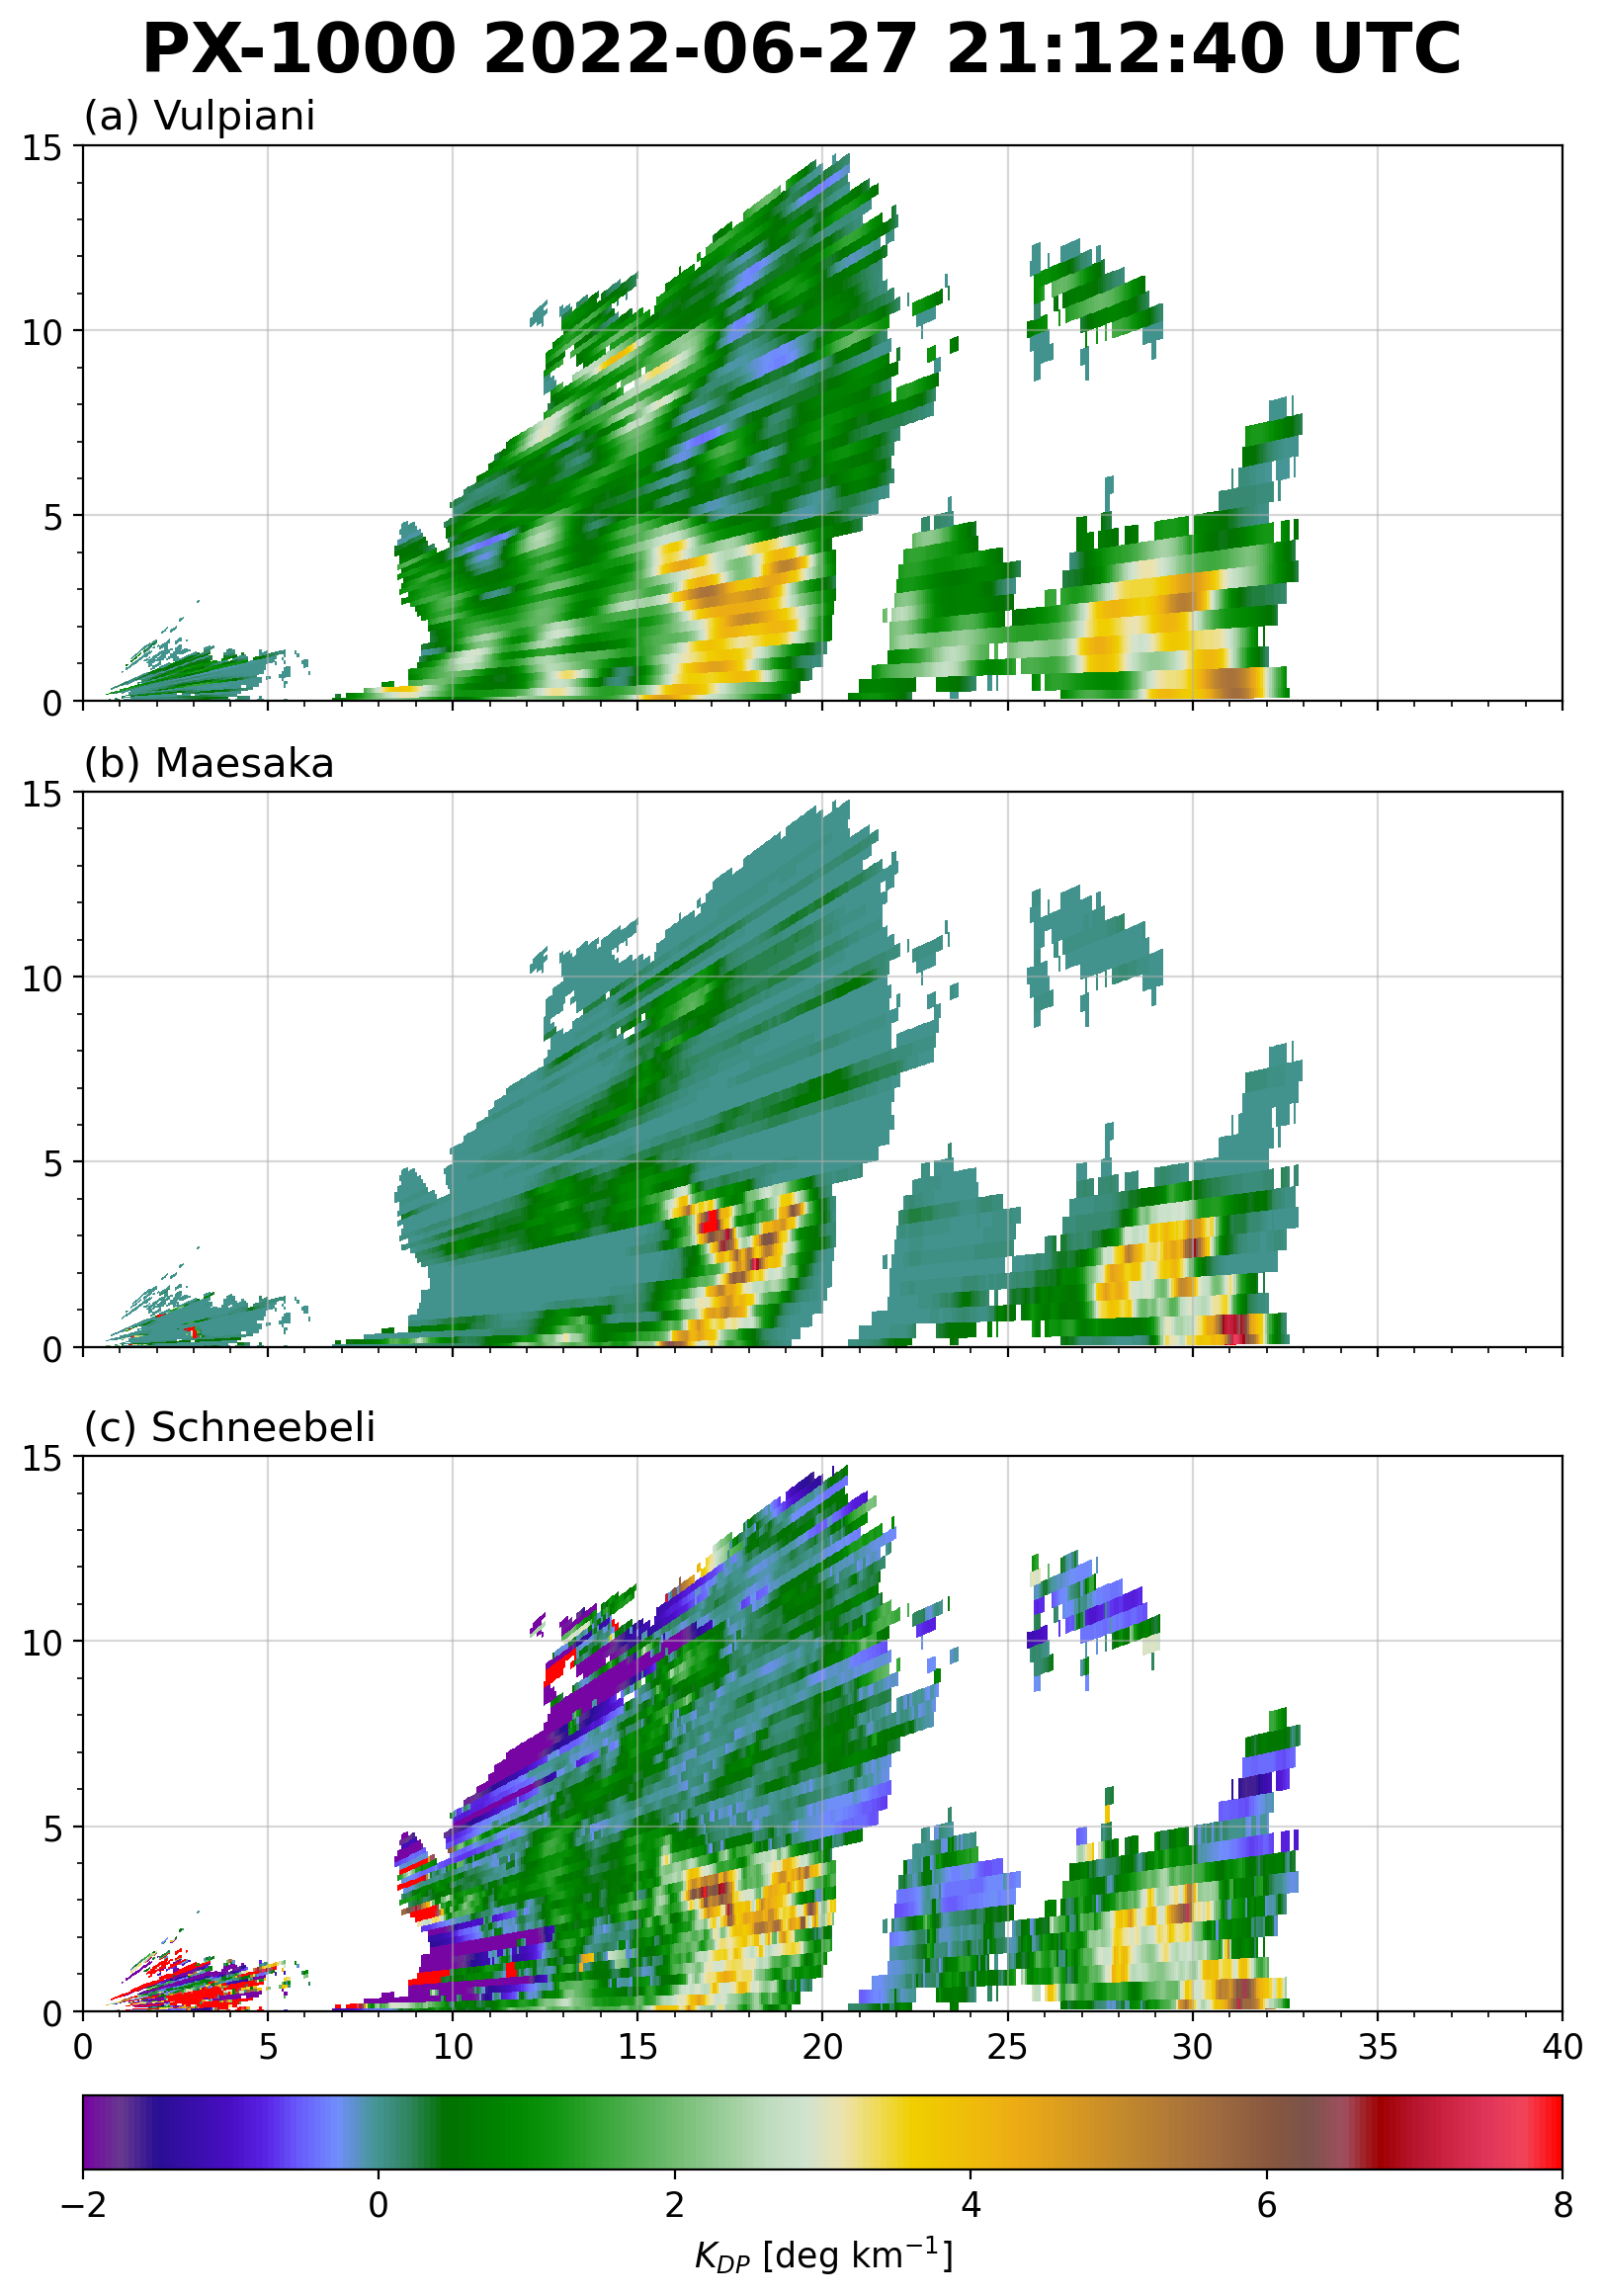

In [6]:
swp = 0
radswp = radar.extract_sweeps([swp])
x, y, z = radar.get_gate_x_y_z(swp)
r = radar.range['data']
kdp_v = radswp.fields['KDP_VULPIANI']['data']
kdp_v_valid = np.where(gf_mask, np.nan, kdp_v)
kdp_m = radswp.fields['KDP_MAESAKA']['data']
kdp_m_valid = np.where(gf_mask, np.nan, kdp_m)
kdp_s = radswp.fields['KDP_SCHNEEBELI']['data']
kdp_s_valid = np.where(gf_mask, np.nan, kdp_s)

fig, axs = plt.subplots(figsize=(8,11.5),
                        nrows=3,
                        sharey=True,
                        sharex=True,
                        constrained_layout=True,
                        dpi=200)
fig.suptitle(f"PX-1000 {tstr}", fontweight='bold', fontsize=25)
vmin, vmax = -2, 8
# Vulpiani
ax = axs[0]
ax.set_title("(a) Vulpiani", loc='left')
ax.pcolormesh(r/1e3, 
              z/1e3, 
              kdp_v_valid,
              vmin=vmin,
              vmax=vmax,
              cmap='Carbone42')
# Maesaka
ax = axs[1]
ax.set_title("(b) Maesaka", loc='left')
ax.pcolormesh(r/1e3, 
              z/1e3, 
              kdp_m_valid,
              vmin=vmin,
              vmax=vmax,
              cmap='Carbone42')
# Schneebeli
ax = axs[2]
ax.set_title("(c) Schneebeli", loc='left')
pcm = ax.pcolormesh(r/1e3,
                    z/1e3,
                    kdp_s_valid,
                    vmin=vmin,
                    vmax=vmax,
                    cmap='Carbone42')
plt.colorbar(pcm, 
             ax=ax, 
             orientation='horizontal', 
             label='$K_{DP}$ [deg km$^{-1}$]')

# clean up
for ax in axs:
    ax.set_ylim(0,15)
    ax.set_xlim(0,40)
    ax.set_aspect('equal')
    ax.grid(alpha=0.5)
    ax.yaxis.set_major_locator(MultipleLocator(5))
    ax.yaxis.set_minor_locator(MultipleLocator(1))
    ax.xaxis.set_major_locator(MultipleLocator(5))
    ax.xaxis.set_minor_locator(MultipleLocator(1))

b) Let's examine the effects of testing different parameters for the Vulpiani method. Perform calculations with 3 iterations using a winsize of 10, and 10 iterations with a window size of 4. Create a plot to compare the different parameters set using Vulpiani (including the original setting with 10 iterations and a window size of 10). Note that Vulpiani requires the window size to be an even number.

In [7]:
# Vulpiani
kdp_dict = pyart.retrieve.kdp_vulpiani(radar, 
                                       gatefilter=gf,
                                       n_iter=10,
                                       windsize=4,
                                       band='X',
                                       psidp_field='PHIDP')
radar.add_field('KDP_VULPIANI2', kdp_dict[0], replace_existing=True)

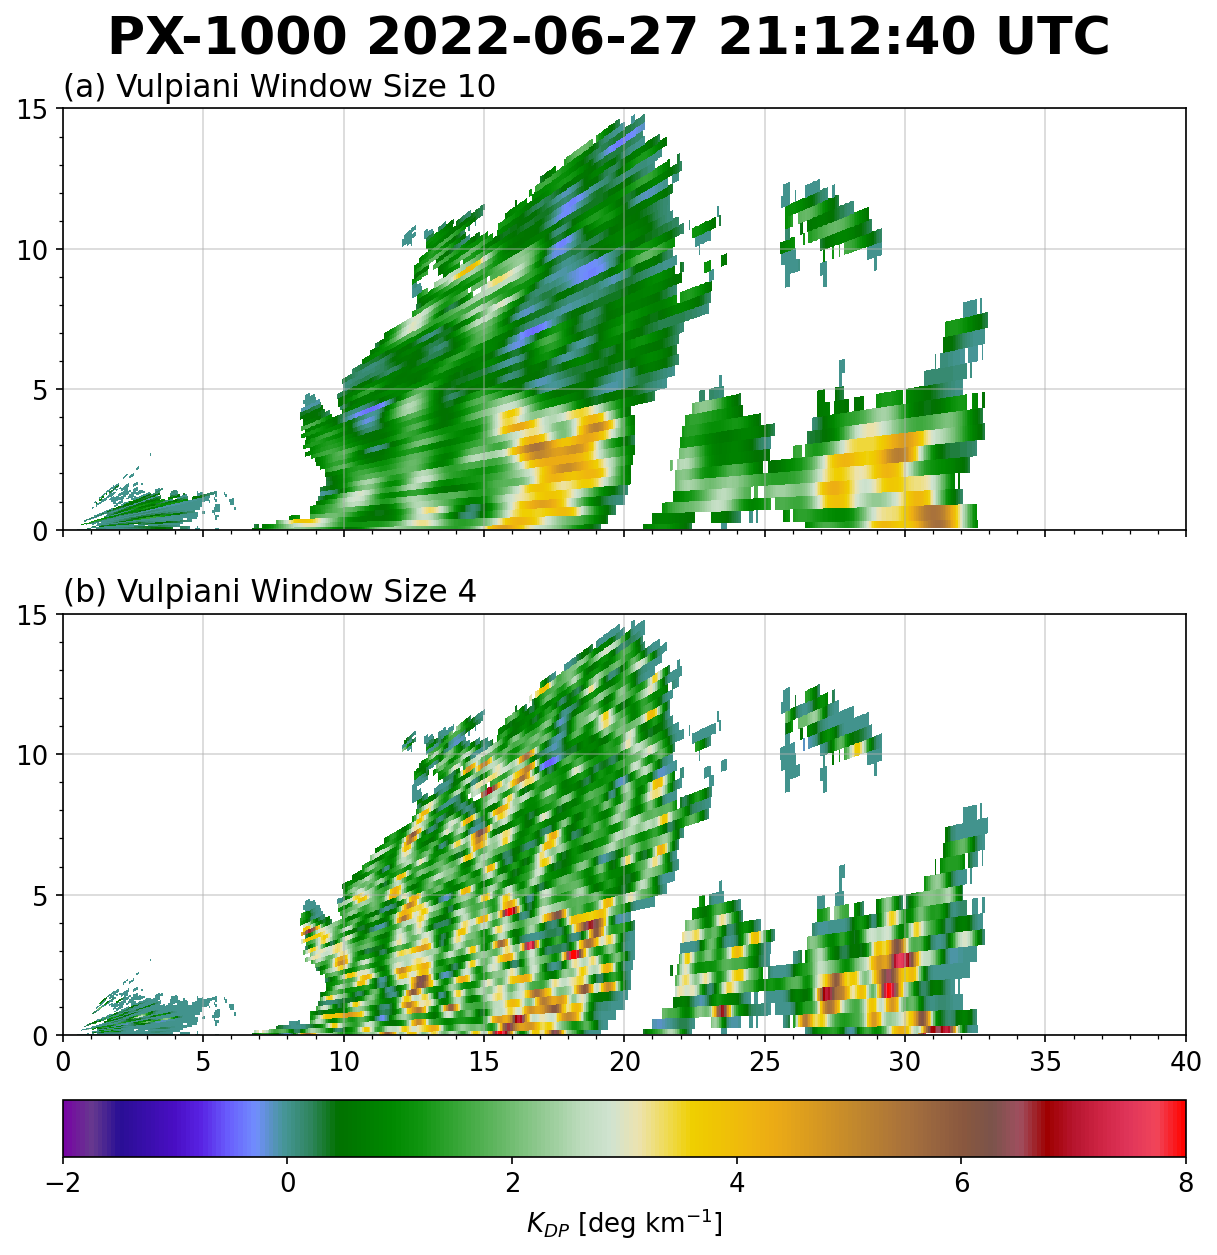

In [8]:
swp = 0
radswp = radar.extract_sweeps([swp])
x, y, z = radar.get_gate_x_y_z(swp)
r = radar.range['data']
kdp_v = radswp.fields['KDP_VULPIANI']['data']
kdp_v2 = radswp.fields['KDP_VULPIANI2']['data']
kdp_v_valid = np.where(gf_mask, np.nan, kdp_v)
kdp_v_valid2 = np.where(gf_mask, np.nan, kdp_v2)

fig, axs = plt.subplots(figsize=(8,8.25),
                        nrows=2,
                        sharey=True,
                        sharex=True,
                        constrained_layout=True,
                        dpi=150)
fig.suptitle(f"PX-1000 {tstr}", fontweight='bold', fontsize=25)
vmin, vmax = -2, 8
# Vulpiani 1
ax = axs[0]
ax.set_title("(a) Vulpiani Window Size 10", loc='left')
ax.pcolormesh(r/1e3, 
              z/1e3, 
              kdp_v_valid,
              vmin=vmin,
              vmax=vmax,
              cmap='Carbone42')
# Maesaka
ax = axs[1]
ax.set_title("(b) Vulpiani Window Size 4", loc='left')
pcm = ax.pcolormesh(r/1e3,
                    z/1e3,
                    kdp_v_valid2,
                    vmin=vmin,
                    vmax=vmax,
                    cmap='Carbone42')
plt.colorbar(pcm, 
             ax=ax, 
             orientation='horizontal', 
             label='$K_{DP}$ [deg km$^{-1}$]')

# clean up
for ax in axs:
    ax.set_ylim(0,15)
    ax.set_xlim(0,40)
    ax.set_aspect('equal')
    ax.grid(alpha=0.5)
    ax.yaxis.set_major_locator(MultipleLocator(5))
    ax.yaxis.set_minor_locator(MultipleLocator(1))
    ax.xaxis.set_major_locator(MultipleLocator(5))
    ax.xaxis.set_minor_locator(MultipleLocator(1))

c) For one of the KDP methods, save the smoothed $\Phi_{DP}$ data into a radar field for later use in attenuation correction. To do this, use kdp_dict[1] in the example above.

In [9]:
# Vulpiani
kdp_dict = pyart.retrieve.kdp_vulpiani(radar, 
                                       gatefilter=gf,
                                       n_iter=10,
                                       windsize=10,
                                       band='X',
                                       psidp_field='PHIDP')
radar.add_field('PHIDP_SMOOTH', kdp_dict[1], replace_existing=True)

Discussion: Provide a short description of each $K_{DP}$ method and its general approach. What are the advantages and disadvantages of each KDP estimation method? Discuss how varying the number of iterations and window sizes impact the results. In your answer, discuss how the $K_{DP}$ method impacts the appearance of $K_{DP}$ overall as well as how it affects the meteorological interpretation (e.g., appearance of a $K_{DP}$)

# 4) Semi-Supervised Hydrometeor Classification Algorithm

The Py-ART hydrometeor classification algorithm uses a semi-supervised approach that combines the unsupervised clustering technique with a supervised method that uses reference scattering libraries. Details are described in Besic et al. (2016) and in the Py-ART <a href="https://arm-doe.github.io/pyart/API/generated/pyart.retrieve.hydroclass_semisupervised.html">documentation</a>.

## Data Preparation
Prior to running the HCA, we have to create a temperature field within our radar dictionary. Py-ART requires a temperature field to perform classification of liquid vs. ice phase precipitation and aid in identifying the melting layer. The temperature field must be specified for each range gate. The code provided below reads data from a sounding on 28 June 2022 (available on Canvas and performs the necessary calculations and conversions to obtain an appropriate temperature field. Make sure you download the text file prior to running the code below.  

Note: If you would like to apply this HCA to other cases, you will need sounding data for that case. You can find text output of archived sounding observations <a href="https://weather.uwyo.edu/upperair/sounding.html?gad_source=1&gclid=EAIaIQobChMInv6Q3P-zhAMVg09HAR1MJwhgEAAYASAAEgJj_PD_BwE">here</a>. The same procedure would work with model sounding data as long as it is gridded to a 2D array consistent with the other radar variables and added to the radar object. 

In [10]:
#Import sounding data 
col_names = ['pressure', 
             'height', 
             'temperature', 
             'dewpoint', 
             'direction',
             'speed']

#!!!!! Modify as needed for the correct file path !!!!!
dsou = "/Users/robbyfrost/Documents/Classes/Radar_Applications/hw2/06282022_sounding.txt"
df = pd.read_fwf(dsou, 
                 skiprows=1, 
                 usecols=[0, 1, 2, 3, 6, 7], 
                 names=col_names)

#Get temperature data from sounding and convert to numpy array
temp = df['temperature'].to_numpy()
height = df['height'].to_numpy()/1000 #Convert to km

num_gates=radar.range['data'].shape[0]
num_el=radar.elevation['data'].shape[0]

#Put the range and elevation data into a common 2D array with 
#dimensions that match the radar data 
rr=repmat(radar.range['data'],num_el,1)/1000 #km
el=np.transpose(repmat(radar.elevation['data'],num_gates,1))

#Calculate beam height for each pixel
ht = rlib.bh_calc(rr,el)

#Interpolate the temperature from the sounding to the radar beam 
#heights
temps=np.interp(ht,height,temp)

#Create a new directionary for temperature and add the field 
#to the radar object
temps_dict={'data':temps}
radar.add_field('temperature',temps_dict,replace_existing=True)

## Semi-Supervised Hydrometeor Classification Algorithm

Apply the semi-supervised hydrometeor classification algorithm to the PX-1000 RHI scan. Save the output to the radar object using add_field(). You will need to specify the names of the radar fields in the arguemnts of the HCA function (e.g., zdr_field='ZDR'). In addition, set the following parameters as follows:
```python
weights=np.array([1., 1., 1., 0.75, 0.5]) #Zh, ZDR, KDP, rhohv, relh (relative height, not relative humidity)
mass_centers=None
```

You may need to add the radar's frequency as well to the radar object using the following code:
```python
radar.instrument_parameters['frequency']={'data':np.array([9.55e9],np.float32)}
```

Create two plots the HCA output in a separate plot, and in a multi-panel plot with HCA, radar reflectivity, $Z_{DR}$, $K_{DP}$, and $\rho_{HV}$. The latter will facilitate intercomparisons between the HCA and radar variables. Sample code is provided for creating an HCA plot to show how the hydrometeor labels can be added to the plot as well as a custom colorbar.

In [11]:
# HCA
radar.instrument_parameters['frequency']={'data':np.array([9.55e9],np.float32)}
hca_dict = pyart.retrieve.hydroclass_semisupervised(
    radar,
    weights=np.array([1., 1., 1., 0.75, 0.5]),
    refl_field='DBZ',
    zdr_field='ZDR',
    kdp_field='KDP_VULPIANI',
    rhv_field='RHOHV',
    mass_centers=None
)
radar.add_field('HCA', hca_dict['hydro'], replace_existing=True)

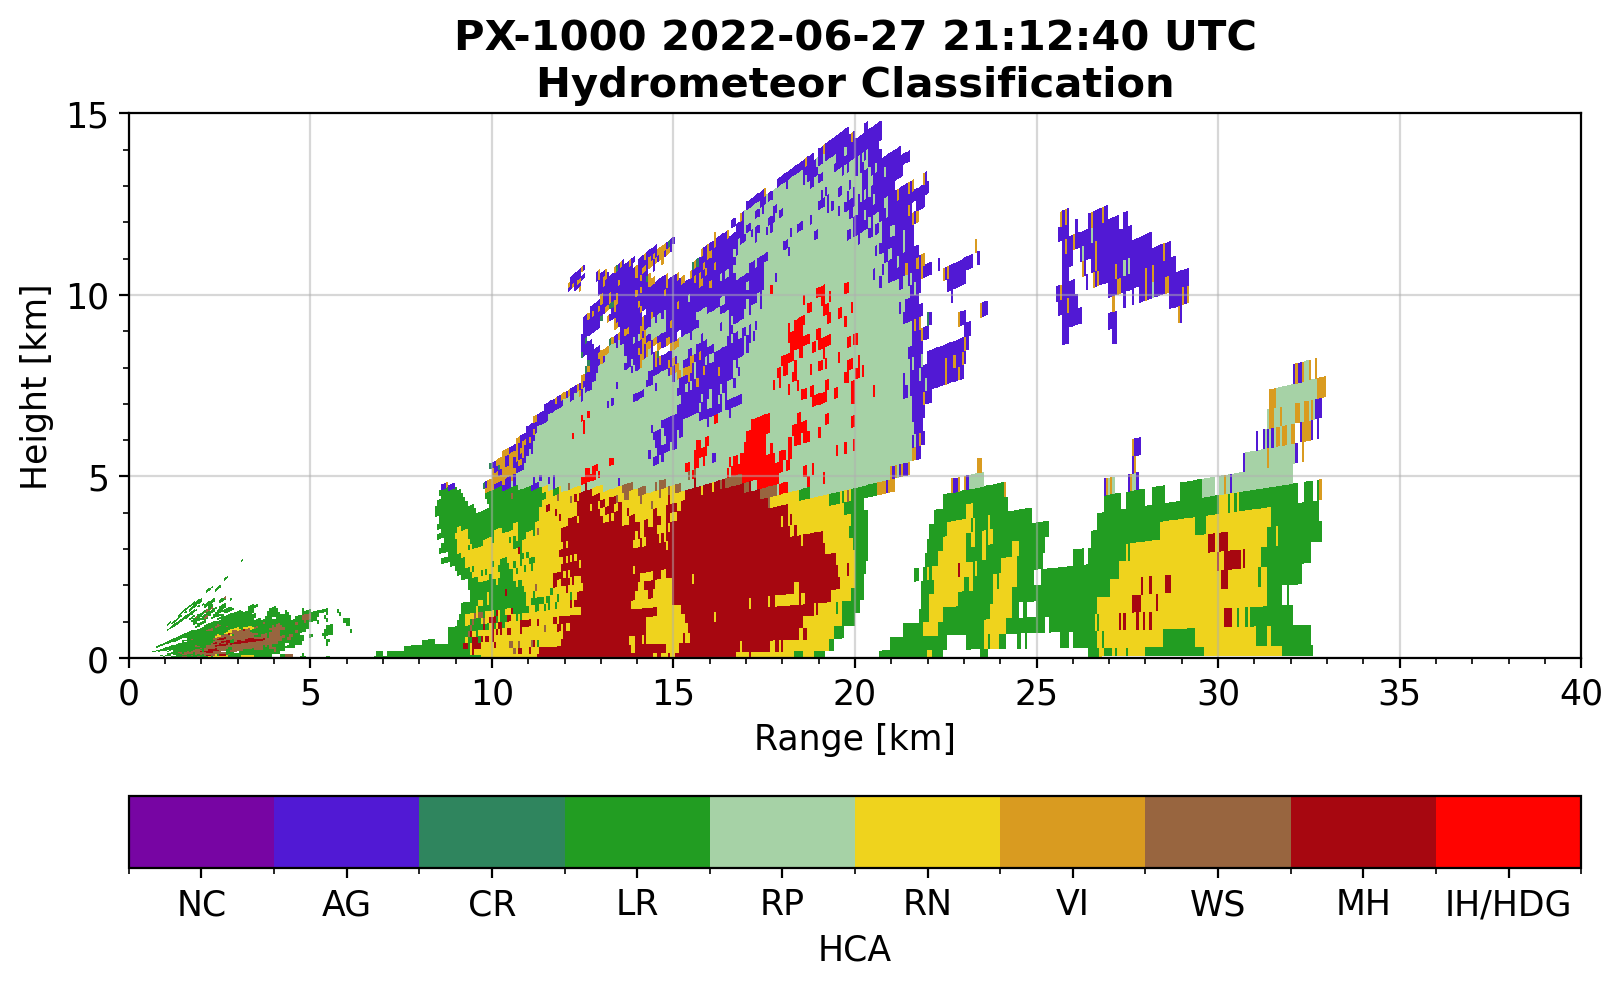

In [16]:
fig,ax = plt.subplots(figsize=(8,5),
                      dpi=200,
                      constrained_layout=True)

ax.set_title(f"PX-1000 {tstr}\nHydrometeor Classification",
             fontweight='bold')
labels = ["NC", "AG", "CR", "LR", "RP", "RN", "VI", "WS", "MH", "IH/HDG"]
ticks = np.arange(len(labels))
boundaries = np.arange(-0.5, len(labels))
norm = mpl.colors.BoundaryNorm(boundaries, 256)
pcm = ax.pcolormesh(r/1e3,
                    z/1e3,
                    np.where(gf_mask, np.nan, radar.fields['HCA']['data']),
                    norm=norm,
                    cmap='Carbone42')
cbar = plt.colorbar(pcm, ax=ax, label='HCA', ticks=ticks, orientation='horizontal')
cbar.set_ticklabels(labels)

ax.set_ylim(0,15)
ax.set_ylabel("Height [km]")
ax.yaxis.set_major_locator(MultipleLocator(5))
ax.yaxis.set_minor_locator(MultipleLocator(1))
ax.set_xlim(0,40)
ax.set_xlabel("Range [km]")
ax.xaxis.set_major_locator(MultipleLocator(5))
ax.xaxis.set_minor_locator(MultipleLocator(1))
ax.set_aspect('equal')
ax.grid(alpha=0.5)

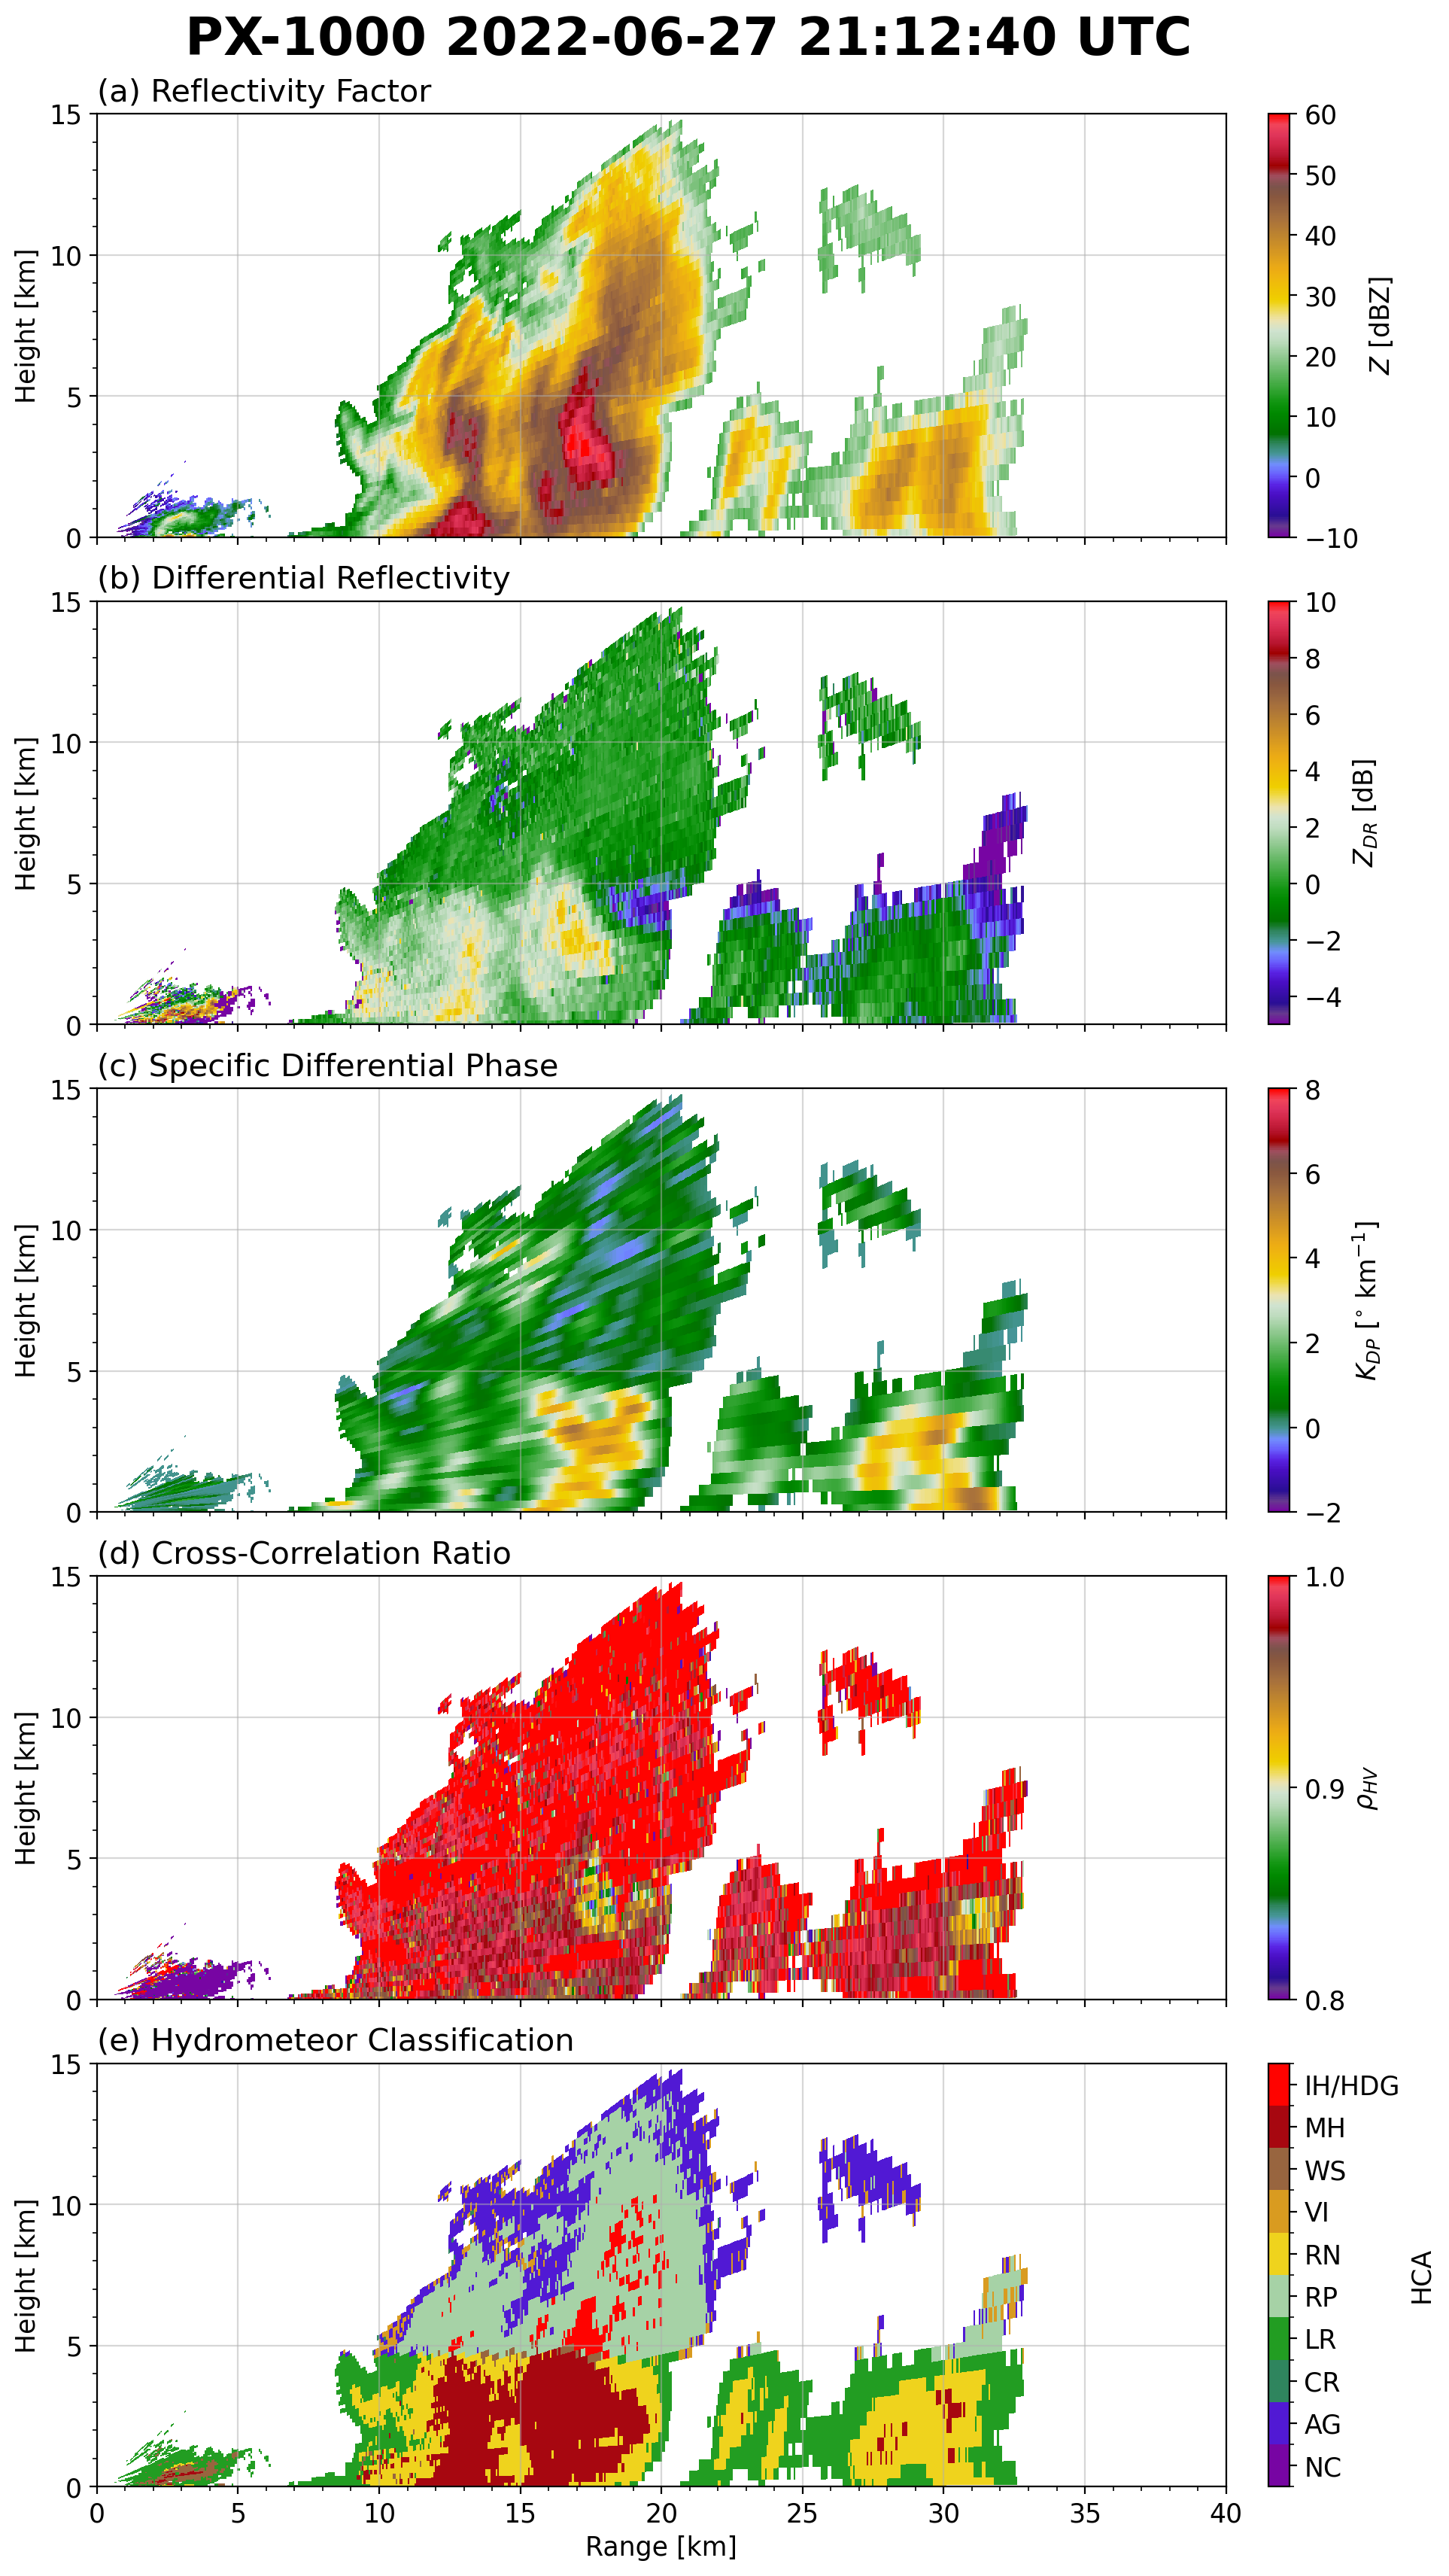

In [26]:
fig, axs = plt.subplots(
    figsize=(10,17),
    nrows=5,
    sharex=True,
    sharey=True,
    constrained_layout=True,
    dpi=200
)
fig.suptitle(f"PX-1000 {tstr}", fontweight='bold', fontsize=25)

# reflectivity
ax = axs[0]
ax.set_title("(a) Reflectivity Factor", loc='left')
vmin, vmax = -10, 60
pcm = ax.pcolormesh(r/1e3,
                    z/1e3,
                    np.where(gf_mask, np.nan, ref),
                    cmap='Carbone42',
                    vmin=vmin,
                    vmax=vmax)
plt.colorbar(pcm, ax=ax, label='$Z$ [dBZ]', pad=0.02)
# zdr
ax = axs[1]
ax.set_title("(b) Differential Reflectivity", loc='left')
vmin, vmax = -5, 10
pcm = ax.pcolormesh(r/1e3,
                    z/1e3,
                    np.where(gf_mask, np.nan, radar.fields['ZDR']['data']),
                    cmap='Carbone42',
                    vmin=vmin,
                    vmax=vmax)
plt.colorbar(pcm, ax=ax, label='$Z_{DR}$ [dB]', pad=0.02)
# kdp
ax = axs[2]
ax.set_title("(c) Specific Differential Phase", loc='left')
vmin, vmax = -2, 8
pcm = ax.pcolormesh(r/1e3,
                    z/1e3,
                    kdp_v_valid,
                    cmap='Carbone42',
                    vmin=vmin,
                    vmax=vmax)
plt.colorbar(pcm, ax=ax, label='$K_{DP}$ [$^{\\circ}$ km$^{-1}$]', pad=0.02)
# rhohv
ax = axs[3]
ax.set_title("(d) Cross-Correlation Ratio", loc='left')
vmin, vmax = 0.8, 1.0
pcm = ax.pcolormesh(r/1e3,
                    z/1e3,
                    np.where(gf_mask, np.nan, radar.fields['RHOHV']['data']),
                    cmap='Carbone42',
                    vmin=vmin,
                    vmax=vmax)
plt.colorbar(pcm, ax=ax, label='$\\rho_{HV}$', pad=0.02, ticks=np.arange(vmin, vmax+0.01, 0.1))
# HCA
ax = axs[4]
ax.set_title("(e) Hydrometeor Classification", loc='left')
labels = ["NC", "AG", "CR", "LR", "RP", "RN", "VI", "WS", "MH", "IH/HDG"]
ticks = np.arange(len(labels))
boundaries = np.arange(-0.5, len(labels))
norm = mpl.colors.BoundaryNorm(boundaries, 256)
pcm = ax.pcolormesh(r/1e3,
                    z/1e3,
                    np.where(gf_mask, np.nan, radar.fields['HCA']['data']),
                    norm=norm,
                    cmap='Carbone42')
cbar = plt.colorbar(pcm, ax=ax, label='HCA', pad=0.02, ticks=ticks)
cbar.set_ticklabels(labels)
ax.set_xlabel("Range [km]")

for ax in axs:
    ax.set_ylim(0,15)
    ax.set_ylabel("Height [km]")
    ax.yaxis.set_major_locator(MultipleLocator(5))
    ax.yaxis.set_minor_locator(MultipleLocator(1))
    ax.set_xlim(0,40)
    ax.xaxis.set_major_locator(MultipleLocator(5))
    ax.xaxis.set_minor_locator(MultipleLocator(1))
    ax.set_aspect('equal')
    ax.grid(alpha=0.5)

**Discussion:** Briefly describe how the semi-supervised HCA works and how it is different from supervised or unsupervised HCAs. How well do you think the hydrometeor classification algorithm is performing? Find an example of a location where you believe the HCA has classified the echoes correctly and incorrectly and explain your reasoning. Since this algorithm was trained in Europe, what issues might arise in applying these HCA membership functions in the United States?

# 5) Attenuation Correction

Py-ART includes two different attention correction methods, the linear phi and the ZPHI method. For the calculate_attenuation_philinear method, attenuation is corrected by on predefined coefficients assuming a linear or power law relationship. The ZPHI method is similar, however, radar reflectivity factor along the radar ray is used as an additional constraint. This additional constraint helps adjust the coefficients depending on the meteorological conditions whereas the linear phi method's coefficients are not adapted to the data.  

Using the same RHI scan, perform attenuation correction using the linear phi and ZPHI methods. For the philinear method, use a_coef=0.31916, beta=0.64884, c=0.15917, and d=1.0804. Make sure you use the smoothed PHIDP field rather than the raw PHIDP. Generate plots of radar reflectivity factor and differential reflectivity before and after correction for both methods. To generate these plots using Py-ART, you will need to add the corrected reflectivity and differential reflectivity fields to your radar dictionary.

**Discussion:** Briefly describe the two methods for attenuation correction and compare the results from the two methods. What are the advantages and disadvantages of the two techniques? What evidence from the radar data could you use to determine if attenuation or differential attenuation correction is working correctly? If hypothetically you wanted to more robustly test the efficacy of the attenuation correction technique, what other measurements could you use?

In [18]:
# phi linear
atten_dict = pyart.correct.calculate_attenuation_philinear(
    radar,
    pia_coef=0.31916,
    # beta=0.64884,
    # c=0.15917,
    # d=1.0804,  
    refl_field='DBZ',
    zdr_field='ZDR',
    phidp_field='PHIDP_SMOOTH',
    gatefilter=gf
)
radar.add_field('DBZ_COR_PHILIN', atten_dict[2], replace_existing=True)
radar.add_field('KDP_COR_PHILIN', atten_dict[3], replace_existing=True)
radar.add_field('ZDR_COR_PHILIN', atten_dict[5], replace_existing=True)

# zphi
atten_dict = pyart.correct.calculate_attenuation_zphi(
    radar,
    refl_field='DBZ',
    zdr_field='ZDR',
    phidp_field='PHIDP_SMOOTH',
    gatefilter=gf
)
radar.add_field('DBZ_COR_ZPHI', atten_dict[2], replace_existing=True)
radar.add_field('KDP_COR_ZPHI', atten_dict[3], replace_existing=True)
radar.add_field('ZDR_COR_ZPHI', atten_dict[5], replace_existing=True)

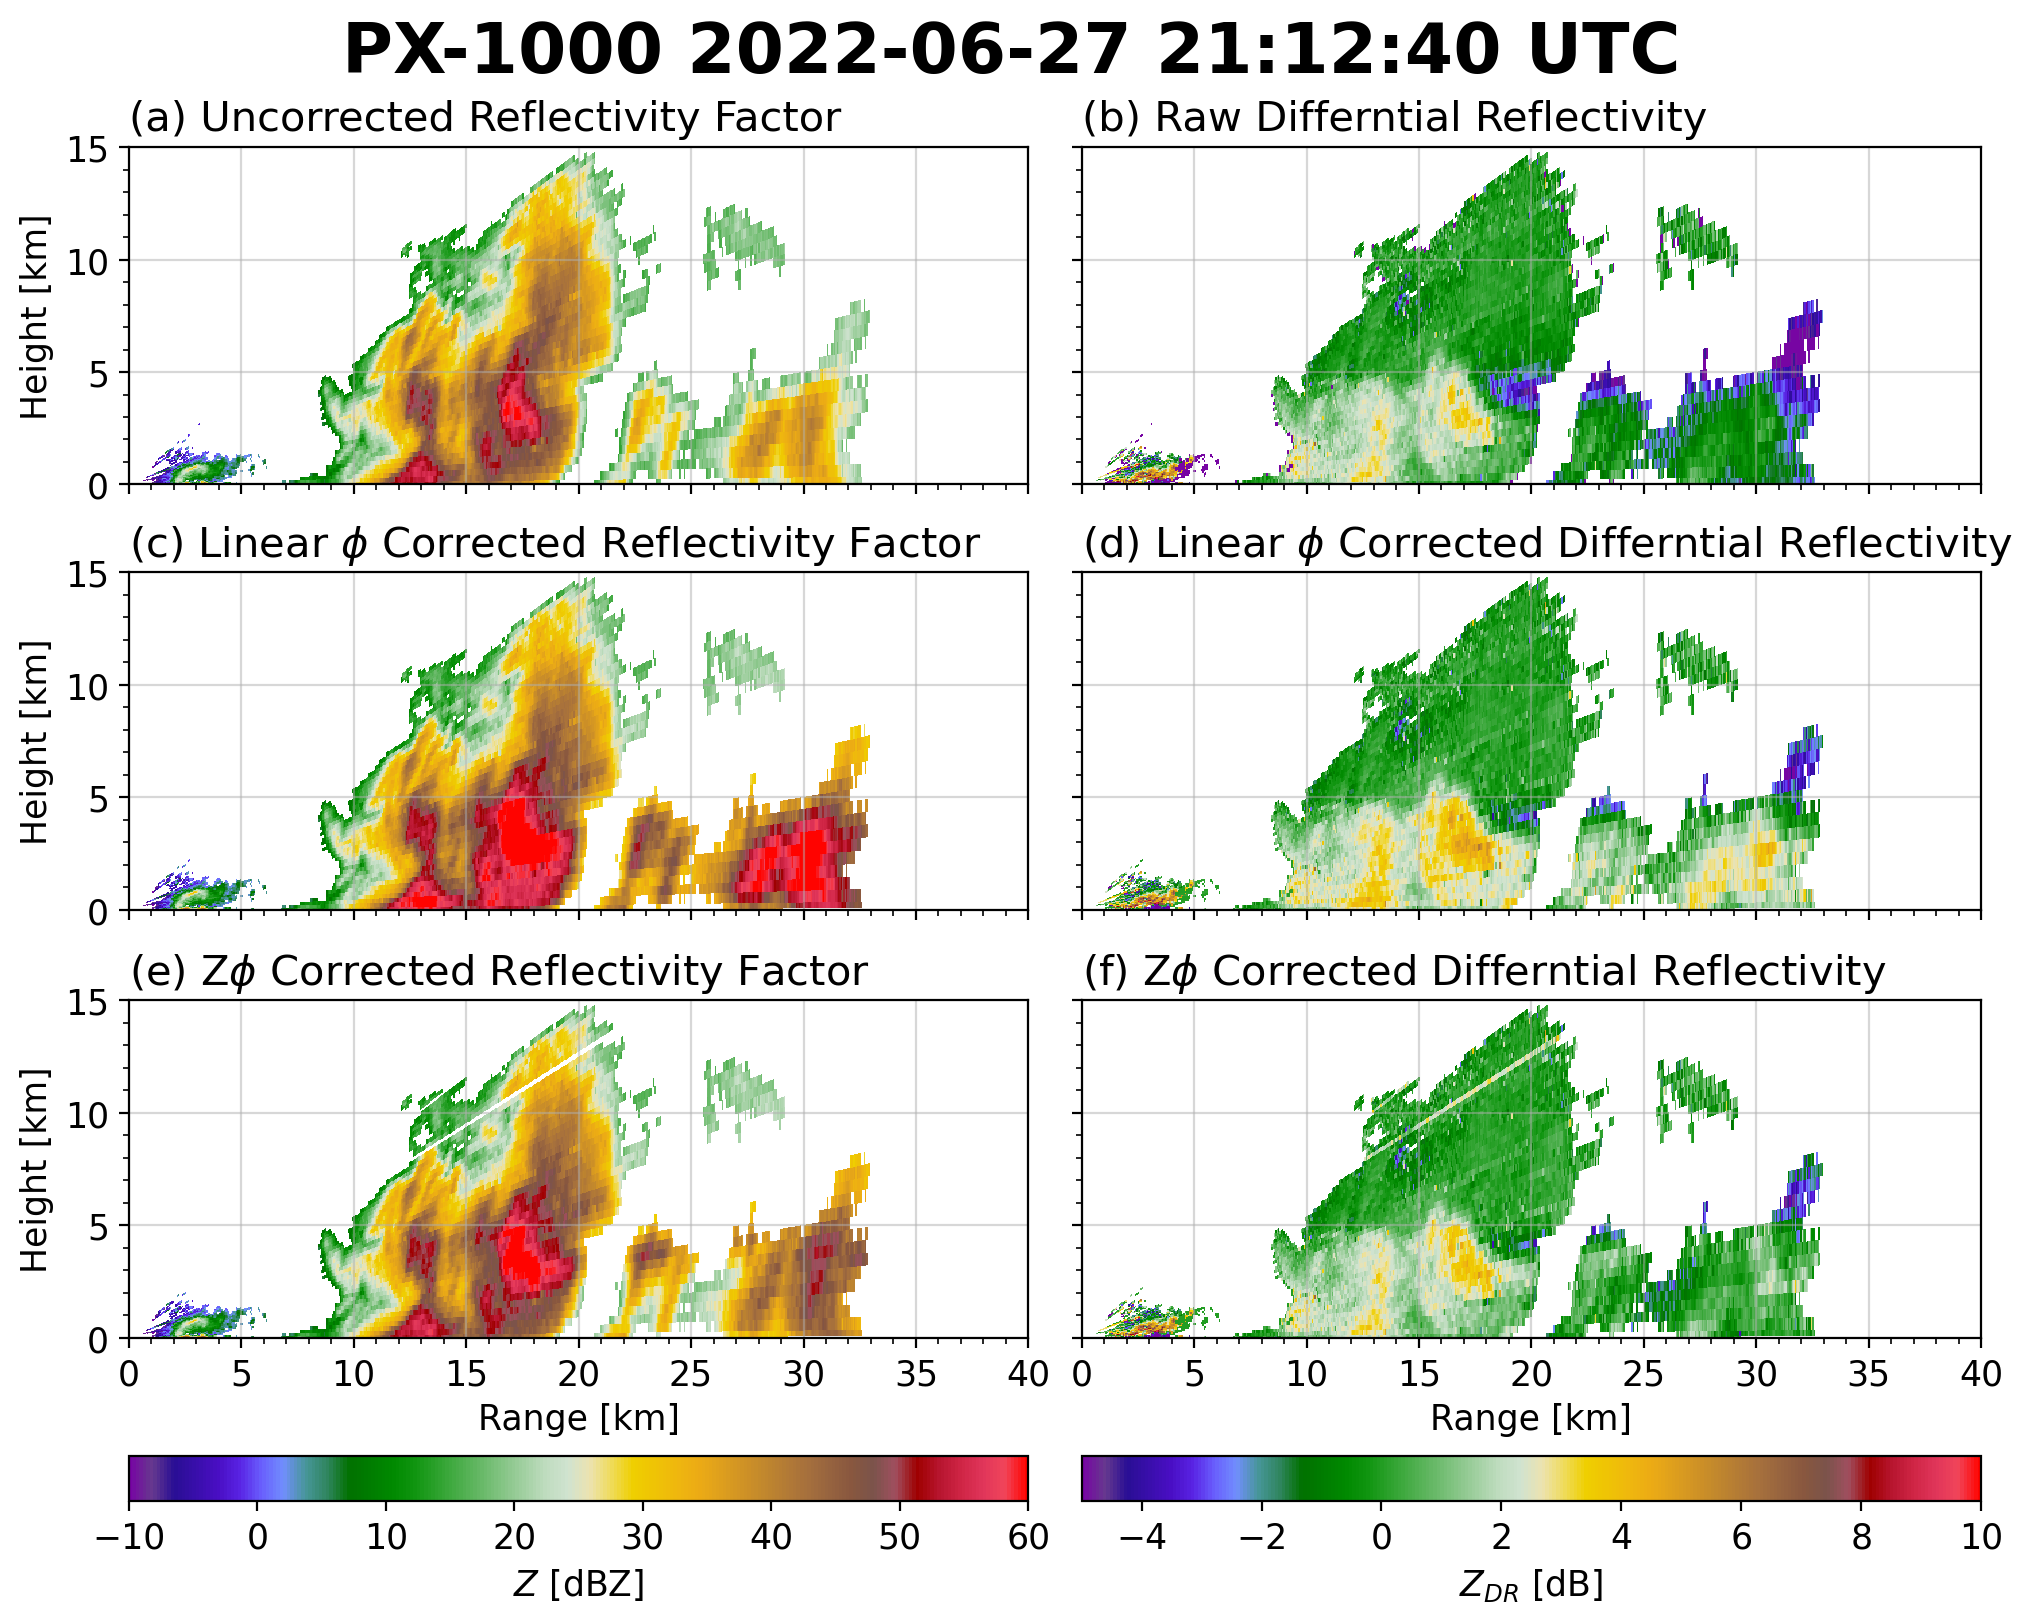

In [27]:
fig, axs = plt.subplots(
    figsize=(10,8),
    ncols=2,
    nrows=3,
    sharex=True,
    sharey=True,
    constrained_layout=True,
    dpi=200
)
fig.suptitle(f"PX-1000 {tstr}", fontweight='bold', fontsize=25)

# raw z
ax = axs[0,0]
ax.set_title("(a) Uncorrected Reflectivity Factor", loc='left')
vmin, vmax = -10, 60
pcm = ax.pcolormesh(r/1e3,
                    z/1e3,
                    np.where(gf_mask, np.nan, ref),
                    cmap='Carbone42',
                    vmin=vmin,
                    vmax=vmax)
ax.set_ylabel("Height [km]")
# philin z
ax = axs[1,0]
ax.set_title("(c) Linear $\\phi$ Corrected Reflectivity Factor", loc='left')
pcm = ax.pcolormesh(r/1e3,
                    z/1e3,
                    np.where(gf_mask, np.nan, radar.fields['DBZ_COR_PHILIN']['data']),
                    cmap='Carbone42',
                    vmin=vmin,
                    vmax=vmax)
ax.set_ylabel("Height [km]")
# zphi z
ax = axs[2,0]
ax.set_title("(e) Z$\\phi$ Corrected Reflectivity Factor", loc='left')
pcm = ax.pcolormesh(r/1e3,
                    z/1e3,
                    np.where(gf_mask, np.nan, radar.fields['DBZ_COR_ZPHI']['data']),
                    cmap='Carbone42',
                    vmin=vmin,
                    vmax=vmax)
ax.set_ylabel("Height [km]")
ax.set_xlabel("Range [km]")
plt.colorbar(pcm, ax=ax, label="$Z$ [dBZ]", orientation='horizontal')
# raw zdr
ax = axs[0,1]
ax.set_title("(b) Raw Differntial Reflectivity", loc='left')
vmin, vmax = -5, 10
pcm = ax.pcolormesh(r/1e3,
                    z/1e3,
                    np.where(gf_mask, np.nan, radar.fields['ZDR']['data']),
                    cmap='Carbone42',
                    vmin=vmin,
                    vmax=vmax)
# philin zdr
ax = axs[1,1]
ax.set_title("(d) Linear $\\phi$ Corrected Differntial Reflectivity", loc='left')
pcm = ax.pcolormesh(r/1e3,
                    z/1e3,
                    np.where(gf_mask, np.nan, radar.fields['ZDR_COR_PHILIN']['data']),
                    cmap='Carbone42',
                    vmin=vmin,
                    vmax=vmax)
# zphi zdr
ax = axs[2,1]
ax.set_title("(f) Z$\\phi$ Corrected Differntial Reflectivity", loc='left')
pcm = ax.pcolormesh(r/1e3,
                    z/1e3,
                    np.where(gf_mask, np.nan, radar.fields['ZDR_COR_ZPHI']['data']),
                    cmap='Carbone42',
                    vmin=vmin,
                    vmax=vmax)
plt.colorbar(pcm, ax=ax, label="$Z_{DR}$ [dB]", orientation='horizontal')
ax.set_xlabel("Range [km]")

for ax in axs.flatten():
    ax.set_ylim(0,15)
    ax.yaxis.set_major_locator(MultipleLocator(5))
    ax.yaxis.set_minor_locator(MultipleLocator(1))
    ax.set_xlim(0,40)
    ax.xaxis.set_major_locator(MultipleLocator(5))
    ax.xaxis.set_minor_locator(MultipleLocator(1))
    ax.set_aspect('equal')
    ax.grid(alpha=0.5)

# 6) Self-Exploration 

Similar to previous assignments, I would like to give you an opportunity to further experiment with these polarimetric radar algorithms and/or use different radar data. You can complete one of the items below, or come up with your own experiment. If you would like to try different provided data sets, see the MobileRadar folder which contains different radar data sets from ESCAPE (thunderstorms near Houston, TX), IMPACTS (snow storms in the Northeast), or TornadicSupercells (RaXPol tornado cases). Some examples are provided below.

a) Using one of the other data sets provided in the class data or your own data set, apply the semi-supervised HCA method. Alternatively, you could repeat the HCA classification above after performing attenuation correction and see how the hydrometeor classifications have changed. Note: You will need to download the corresponding sounding data for the case.

b) Test different KDP parameters in either the Maesaka or Schneebeli method and compare the results to the default settings. Alternatively, you can compare different KDP retrieval techniques using a different radar data set.

c) Either using the Py-ART algorithms for rain rate estimation or implementing the equation yourself, perform estimation of rainfall rates using a traditional Z-R relationship and a dual-polarization-based retrieval (e.g., R=f(Kdp)). The pyart functions are in the retrieve module and are named pyart.retrieve.est_rain_rate_kdp, pyart.retrieve.est_rain_rate_z, etc.  

In [28]:
# HCA
radar.instrument_parameters['frequency']={'data':np.array([9.55e9],np.float32)}
hca_dict = pyart.retrieve.hydroclass_semisupervised(
    radar,
    weights=np.array([1., 1., 1., 0.75, 0.5]),
    refl_field='DBZ_COR_ZPHI',
    zdr_field='ZDR_COR_ZPHI',
    kdp_field='KDP_COR_ZPHI',
    rhv_field='RHOHV',
    mass_centers=None
)
radar.add_field('HCA_ATT_COR_ZPHI', hca_dict['hydro'], replace_existing=True)

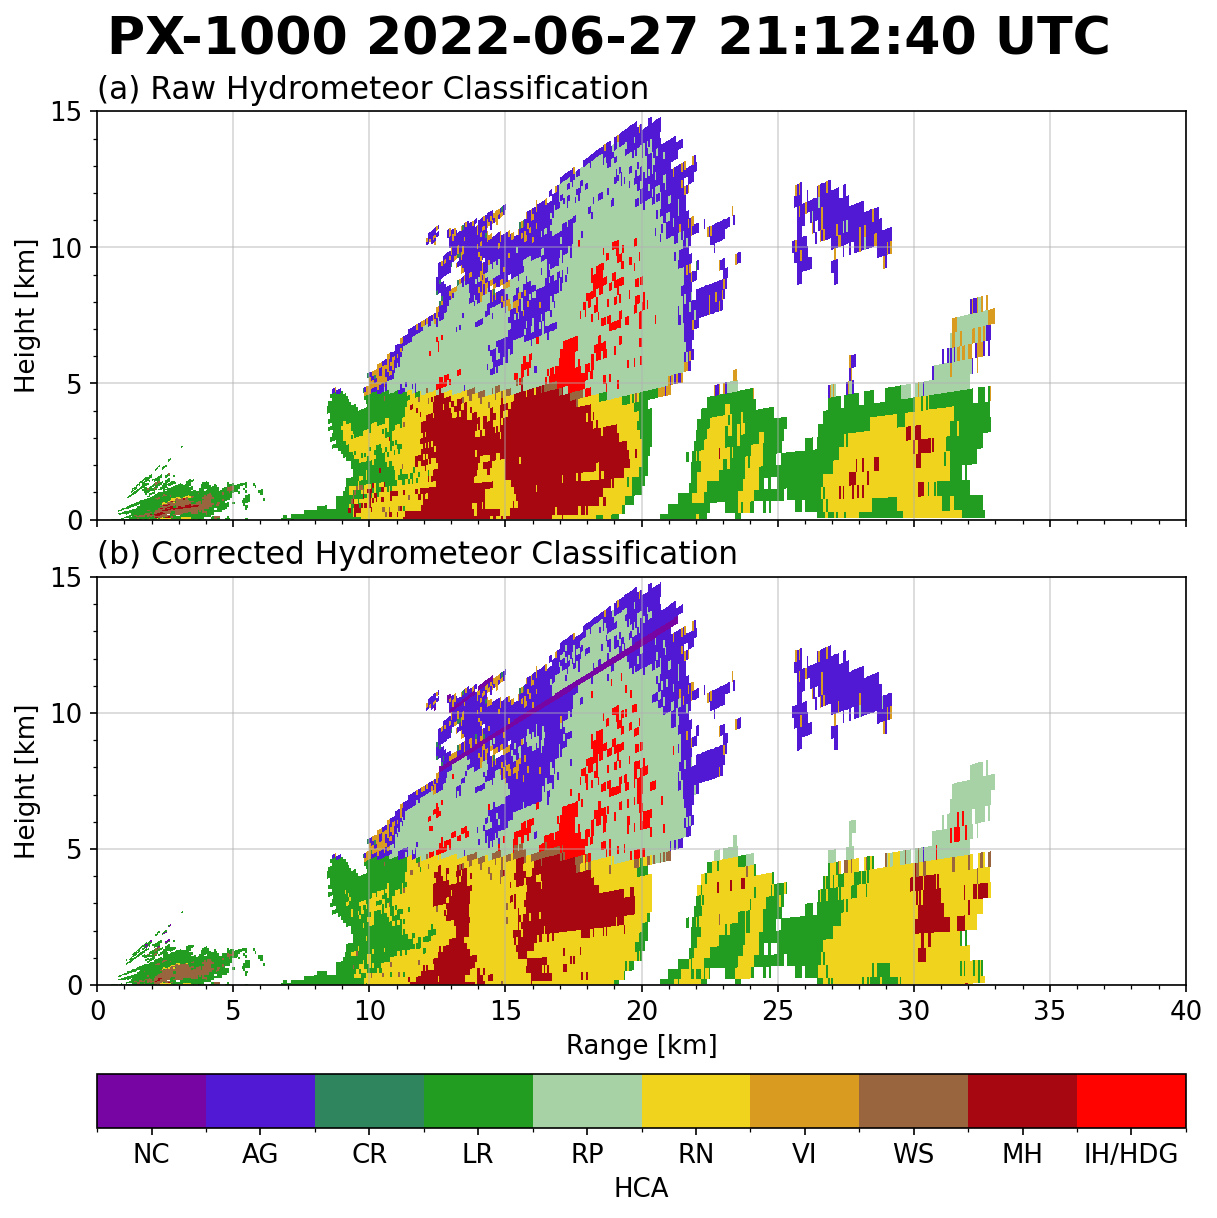

In [30]:
fig, axs = plt.subplots(
    figsize=(8,8),
    nrows=2,
    sharex=True,
    sharey=True,
    constrained_layout=True,
    dpi=150
)
fig.suptitle(f"PX-1000 {tstr}", fontweight='bold', fontsize=25)
labels = ["NC", "AG", "CR", "LR", "RP", "RN", "VI", "WS", "MH", "IH/HDG"]
ticks = np.arange(len(labels))
boundaries = np.arange(-0.5, len(labels))
norm = mpl.colors.BoundaryNorm(boundaries, 256)

# Raw HCA
ax = axs[0]
ax.set_title("(a) Raw Hydrometeor Classification", loc='left')
pcm = ax.pcolormesh(r/1e3,
                    z/1e3,
                    np.where(gf_mask, np.nan, radar.fields['HCA']['data']),
                    norm=norm,
                    cmap='Carbone42')

# Raw HCA
ax = axs[1]
ax.set_title("(b) Corrected Hydrometeor Classification", loc='left')
pcm = ax.pcolormesh(r/1e3,
                    z/1e3,
                    np.where(gf_mask, np.nan, radar.fields['HCA_ATT_COR_ZPHI']['data']),
                    norm=norm,
                    cmap='Carbone42')
cbar = plt.colorbar(pcm, ax=ax, label='HCA', pad=0.03, ticks=ticks, orientation='horizontal')
cbar.set_ticklabels(labels)
ax.set_xlabel("Range [km]")

# clean up
for ax in axs:
    ax.set_ylim(0,15)
    ax.set_ylabel("Height [km]")
    ax.yaxis.set_major_locator(MultipleLocator(5))
    ax.yaxis.set_minor_locator(MultipleLocator(1))
    ax.set_xlim(0,40)
    ax.xaxis.set_major_locator(MultipleLocator(5))
    ax.xaxis.set_minor_locator(MultipleLocator(1))
    ax.set_aspect('equal')
    ax.grid(alpha=0.5)